# 04 — Class Prior Sensitivity

Experiment 3: How sensitive is nnPU to the class prior estimate?

Vary the assumed prior from 0.5x to 2x the true value (0.0277), 3 seeds each.

**Expected runtime:** ~10 minutes (18 runs)

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from training import train_nnpu, find_best_threshold, load_split_embeddings

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3", "xtick.color": "#8b949e", "ytick.color": "#8b949e",
    "grid.color": "#30363d", "grid.alpha": 0.5,
    "legend.facecolor": "#161b22", "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3", "font.size": 12, "figure.dpi": 150,
})

EMB_DIR = str(ROOT / "data" / "processed" / "embeddings")
SEEDS = [42, 123, 456]
TRUE_PRIOR = 0.0277
PRIORS = [0.0139, 0.0208, 0.0277, 0.0346, 0.0416, 0.0554]
PRIOR_LABELS = {0.0139: "0.5x", 0.0208: "0.75x", 0.0277: "1.0x",
                0.0346: "1.25x", 0.0416: "1.5x", 0.0554: "2.0x"}

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

## 1. Run prior sweep

In [2]:
val = load_split_embeddings(EMB_DIR, "valid")
test = load_split_embeddings(EMB_DIR, "test")
X_val = torch.tensor(val["embeddings"], dtype=torch.float32).to(device)
X_test = torch.tensor(test["embeddings"], dtype=torch.float32).to(device)

rows = []
for prior in PRIORS:
    for seed in SEEDS:
        model, hist = train_nnpu(EMB_DIR, labeled_frac=0.20, split_seed=seed,
                                  model_seed=seed, prior=prior, device=device)
        thr, _ = find_best_threshold(model, X_val, val["labels"])
        with torch.no_grad():
            probs = model.predict_proba(X_test).cpu().numpy()
        preds = (probs >= thr).astype(int)
        
        rows.append({
            "prior": prior, "prior_mult": PRIOR_LABELS[prior], "seed": seed,
            "threshold": round(thr, 2),
            "f1": round(f1_score(test["labels"], preds), 4),
            "auroc": round(roc_auc_score(test["labels"], probs), 4),
            "auprc": round(average_precision_score(test["labels"], probs), 4),
        })
    print(f"  Prior {PRIOR_LABELS[prior]} ({prior:.4f}): done")

df = pd.DataFrame(rows)
print(f"\n{len(df)} runs complete")

  Prior 0.5x (0.0139): done


  Prior 0.75x (0.0208): done


  Prior 1.0x (0.0277): done


  Prior 1.25x (0.0346): done


  Prior 1.5x (0.0416): done


  Prior 2.0x (0.0554): done

18 runs complete


## 2. Prior sensitivity figure

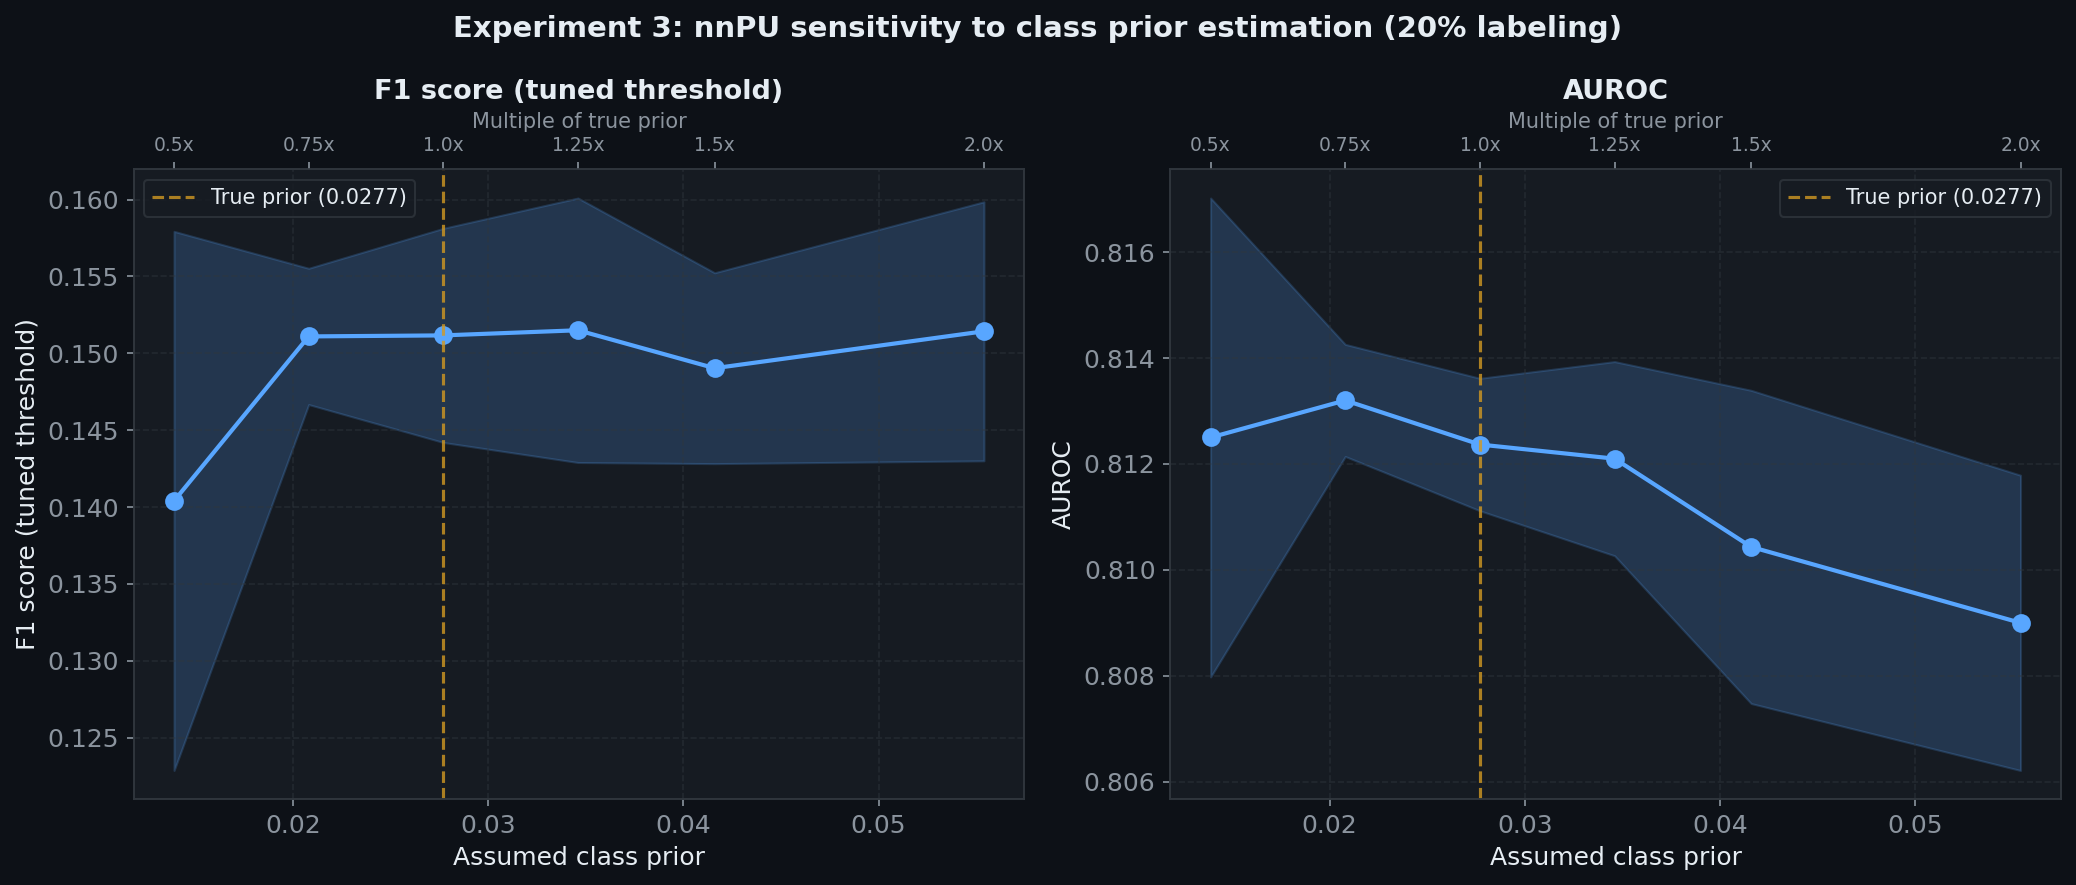


=== Prior sensitivity summary ===

   0.5x (pi=0.0139): F1=0.1404+/-0.0175  AUROC=0.8125+/-0.0045
  0.75x (pi=0.0208): F1=0.1511+/-0.0044  AUROC=0.8132+/-0.0011
   1.0x (pi=0.0277): F1=0.1512+/-0.0070  AUROC=0.8124+/-0.0013
  1.25x (pi=0.0346): F1=0.1515+/-0.0086  AUROC=0.8121+/-0.0018
   1.5x (pi=0.0416): F1=0.1490+/-0.0062  AUROC=0.8104+/-0.0030
   2.0x (pi=0.0554): F1=0.1514+/-0.0084  AUROC=0.8090+/-0.0028


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, ylabel in [(axes[0], "f1", "F1 score (tuned threshold)"),
                            (axes[1], "auroc", "AUROC")]:
    means = df.groupby("prior")[metric].mean()
    stds = df.groupby("prior")[metric].std()
    priors = means.index.values
    
    ax.plot(priors, means.values, "o-", color="#58a6ff", markersize=8, linewidth=2)
    ax.fill_between(priors, means.values - stds.values, means.values + stds.values,
                    color="#58a6ff", alpha=0.2)
    ax.axvline(x=TRUE_PRIOR, color="#d29922", linestyle="--", alpha=0.8,
               label=f"True prior ({TRUE_PRIOR})")
    
    ax.set_xlabel("Assumed class prior")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")
    
    # Secondary axis with multiplier labels
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(priors)
    ax2.set_xticklabels([PRIOR_LABELS[p] for p in priors], fontsize=9)
    ax2.set_xlabel("Multiple of true prior", fontsize=10, color="#8b949e")
    ax2.tick_params(colors="#8b949e")

fig.suptitle("Experiment 3: nnPU sensitivity to class prior estimation (20% labeling)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb04_prior_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary
print("\n=== Prior sensitivity summary ===\n")
for prior in PRIORS:
    m = df[df["prior"] == prior]
    print(f"  {PRIOR_LABELS[prior]:>5s} (pi={prior:.4f}): F1={m.f1.mean():.4f}+/-{m.f1.std():.4f}  "
          f"AUROC={m.auroc.mean():.4f}+/-{m.auroc.std():.4f}")

In [4]:
# Save CSV
out_path = ROOT / "experiments" / "logs" / "exp3_prior.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df)} rows to {out_path}")

Saved 18 rows to /Users/dbenson/mygit/stat3106/project/experiments/logs/exp3_prior.csv


## Summary

- nnPU is robust to prior misspecification: F1 varies by ~0.01 across 0.5x to 2.0x the true prior
- AUROC is similarly stable (range ~0.805 to 0.814)
- A practitioner does not need to know the exact class prior for nnPU to work
- Self-training (not tested here) does not need the prior at all, which is a practical advantage

**Outputs:**
- `experiments/logs/exp3_prior.csv` — 18 rows (6 priors x 3 seeds)
- `figures/nb04_prior_sensitivity.png`

**Next: Notebook 05 (ablations)**